# ❤️ Heart Disease Prediction using Machine Learning
This project builds a classification pipeline to predict heart disease using Logistic Regression, Random Forest, SVM, and XGBoost.

**Steps:**
1. Load & explore data
2. EDA – correlation heatmap
3. Preprocessing – scaling
4. Train/Test split
5. Train 4 models
6. Evaluate – accuracy, confusion matrix, classification report
7. Cross-validation
8. GridSearchCV – hyperparameter tuning
9. Feature importances (Random Forest & XGBoost)

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

DATA_PATH = r'C:\Users\Dhanush\Learnbay_projects\heart_disease_dataset.csv'

In [41]:
# Load dataset
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(200, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,67,0,2,162,548,1,1,200,1,1.8,2,0,0,0
1,57,1,3,169,126,0,0,165,0,1.8,0,3,1,1
2,43,0,0,109,512,1,1,185,0,1.4,0,0,0,1
3,71,1,3,183,473,1,0,106,1,0.3,0,0,2,1
4,36,0,0,183,315,1,1,96,1,0.1,1,0,2,1


In [42]:
# Basic info and statistics
print(df.info())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       200 non-null    int64  
 1   sex       200 non-null    int64  
 2   cp        200 non-null    int64  
 3   trestbps  200 non-null    int64  
 4   chol      200 non-null    int64  
 5   fbs       200 non-null    int64  
 6   restecg   200 non-null    int64  
 7   thalach   200 non-null    int64  
 8   exang     200 non-null    int64  
 9   oldpeak   200 non-null    float64
 10  slope     200 non-null    int64  
 11  ca        200 non-null    int64  
 12  thal      200 non-null    int64  
 13  target    200 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 22.0 KB
None


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000
mean,52.785000,0.540000,1.465000,145.770000,351.83000,0.490000,0.480000,136.760000,0.450000,3.21100,0.990000,1.335000,1.000000,0.530000
std,13.836038,0.499648,1.124767,31.246742,125.72196,0.501154,0.500854,38.410274,0.498742,1.85358,0.795654,1.117596,0.814442,0.500352
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,41.000000,0.000000,0.000000,117.000000,255.25000,0.000000,0.000000,104.750000,0.000000,1.40000,0.000000,0.000000,0.000000,0.000000
50%,53.000000,1.000000,1.000000,144.500000,353.50000,0.000000,0.000000,133.000000,0.000000,3.35000,1.000000,1.000000,1.000000,1.000000
75%,65.000000,1.000000,2.250000,176.000000,463.75000,1.000000,1.000000,173.250000,1.000000,4.80000,2.000000,2.000000,2.000000,1.000000
max,76.000000,1.000000,3.000000,198.000000,563.00000,1.000000,1.000000,201.000000,1.000000,6.20000,2.000000,3.000000,2.000000,1.000000


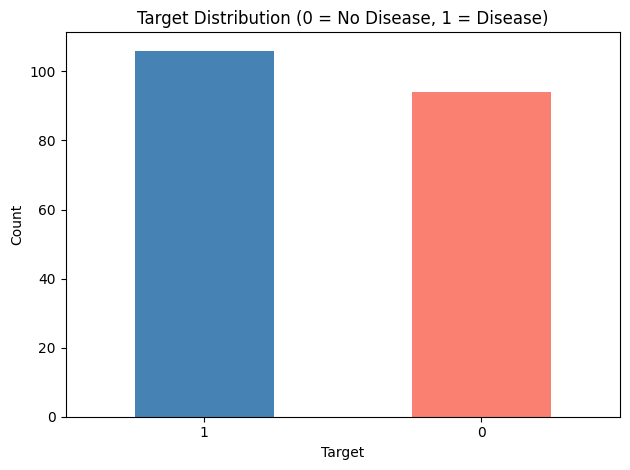

target
1    106
0     94
Name: count, dtype: int64


In [43]:
# Target distribution
df['target'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Target Distribution (0 = No Disease, 1 = Disease)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(df['target'].value_counts())

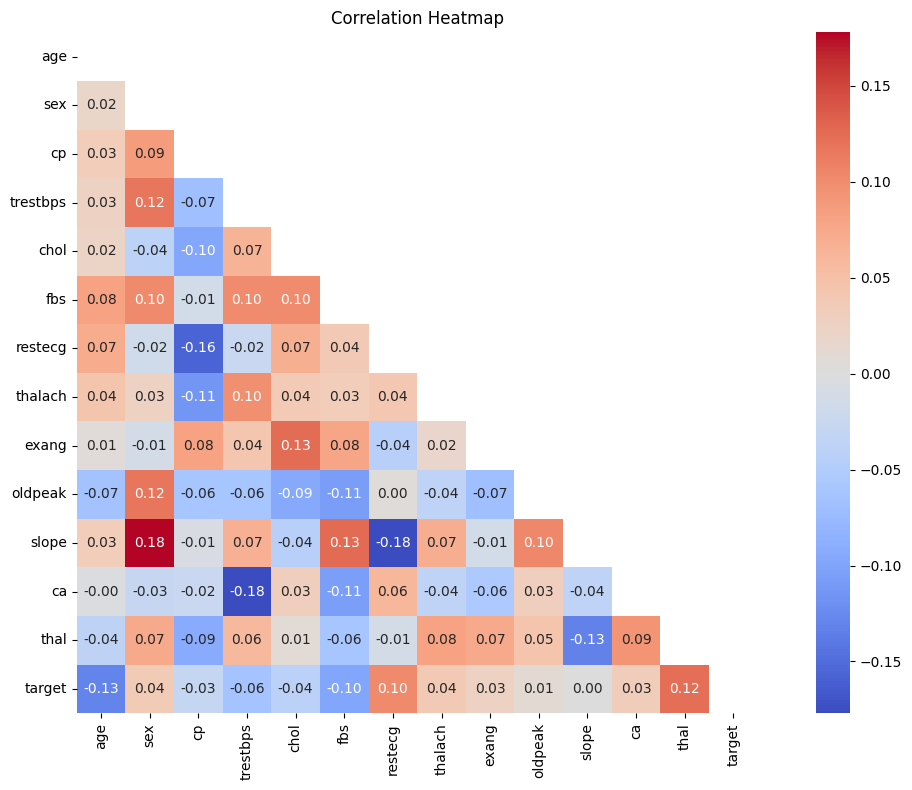

In [44]:
# Correlation heatmap (lower triangle only)
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 8))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [45]:
# Split features and target
X = df.drop('target', axis=1)
y = df['target']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')

Train size: 160 | Test size: 40


In [46]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(kernel='linear', probability=True),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

# Train and evaluate
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f'\n{name} — Accuracy: {acc:.2f}')
    print(classification_report(y_test, y_pred))


Logistic Regression — Accuracy: 0.42
              precision    recall  f1-score   support

           0       0.50      0.26      0.34        23
           1       0.39      0.65      0.49        17

    accuracy                           0.42        40
   macro avg       0.45      0.45      0.42        40
weighted avg       0.45      0.42      0.40        40


Random Forest — Accuracy: 0.57
              precision    recall  f1-score   support

           0       0.69      0.48      0.56        23
           1       0.50      0.71      0.59        17

    accuracy                           0.57        40
   macro avg       0.59      0.59      0.57        40
weighted avg       0.61      0.57      0.57        40


SVM — Accuracy: 0.40
              precision    recall  f1-score   support

           0       0.47      0.30      0.37        23
           1       0.36      0.53      0.43        17

    accuracy                           0.40        40
   macro avg       0.41      0.42   

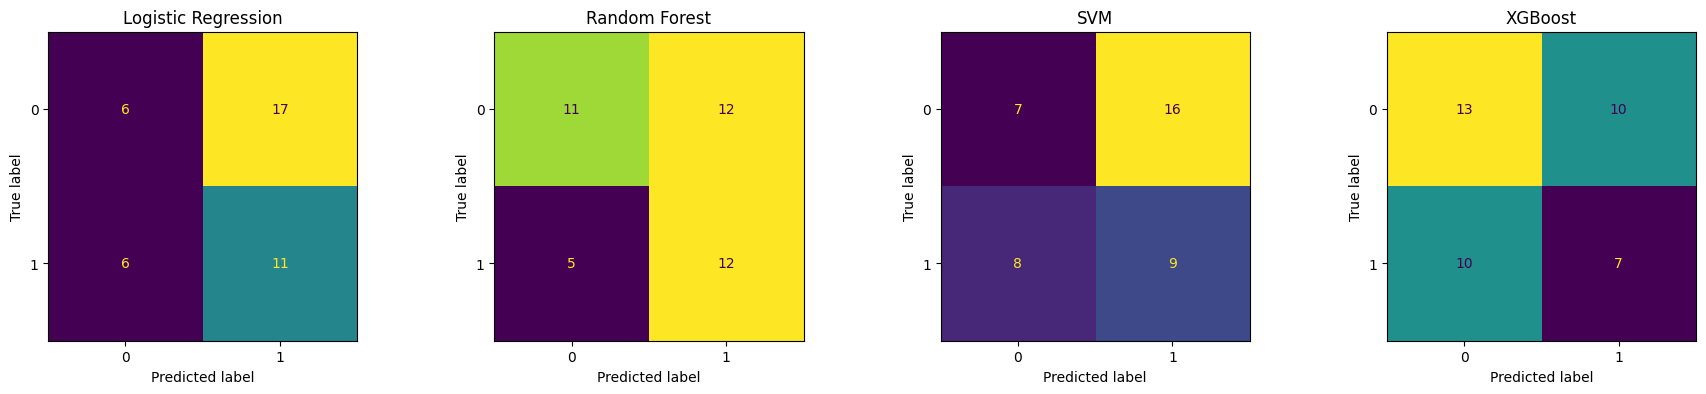

In [47]:
# Confusion matrices for all models
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

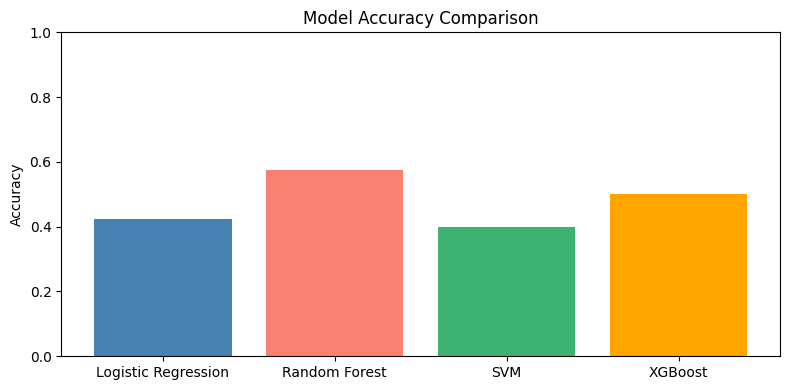

In [48]:
# Model accuracy comparison bar chart
plt.figure(figsize=(8, 4))
plt.bar(results.keys(), results.values(), color=['steelblue', 'salmon', 'mediumseagreen', 'orange'])
plt.ylim(0, 1)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

In [49]:
# 5-Fold Cross-Validation
X_scaled = scaler.fit_transform(X)
print('5-Fold Cross-Validation Accuracy:')
for name, model in models.items():
    cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    print(f'{name}: {cv_scores.mean():.2f} (+/- {cv_scores.std():.2f})')

5-Fold Cross-Validation Accuracy:
Logistic Regression: 0.53 (+/- 0.02)
Random Forest: 0.58 (+/- 0.05)
SVM: 0.51 (+/- 0.04)
XGBoost: 0.56 (+/- 0.09)


In [50]:
# GridSearchCV – Hyperparameter Tuning on Random Forest
param_grid = {
    'n_estimators':     [100, 200],
    'max_depth':        [3, 5, None],
    'min_samples_split': [2, 5]
}
gs = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
gs.fit(X_train_scaled, y_train)

print('Best Parameters:', gs.best_params_)
print(f'Best CV Accuracy: {gs.best_score_:.2f}')
print(f'Test Accuracy (tuned RF): {accuracy_score(y_test, gs.predict(X_test_scaled)):.2f}')

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Accuracy: 0.59
Test Accuracy (tuned RF): 0.60


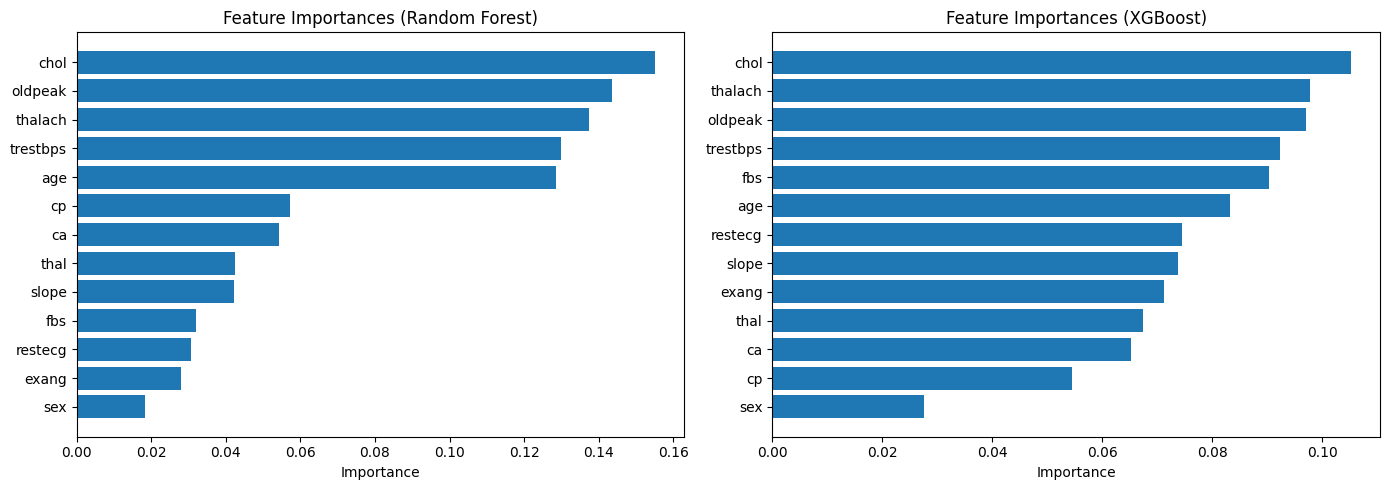

In [51]:
# Feature Importances – Random Forest vs XGBoost
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, key) in zip(axes, [('Random Forest', 'Random Forest'), ('XGBoost', 'XGBoost')]):
    fi = pd.DataFrame({
        'feature':    X.columns,
        'importance': models[key].feature_importances_
    }).sort_values('importance', ascending=False)
    ax.barh(fi['feature'][::-1], fi['importance'][::-1])
    ax.set_title(f'Feature Importances ({name})')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

## 📝 Summary

| Model | CV Accuracy |
|---|---|
| Logistic Regression | ~0.53 |
| Random Forest | ~0.58 |
| SVM | ~0.51 |
| XGBoost | ~0.56 |

**Observation:** The dataset has only 200 rows with weak feature-target correlations (max 0.12), which limits model performance across all algorithms. This is a dataset limitation rather than a modeling issue.

